# 04-Architecting CNNs in PyTorch

In our previous lessons, we mastered the individual geometric building blocks of Computer Vision:

1. We translated physical light into 3D Tensors (Lesson 01).
2. We used Convolutions to extract local spatial features (Lesson 02).
3. We used Max Pooling to compress dimensions and achieve translation invariance (Lesson 03).

Now, we must assemble these isolated mathematical operations into a cohesive, end-to-end learning engine capable of looking at a raw image and predicting exactly what it is. We are going to build our first complete **Convolutional Neural Network (CNN)**.

Let's set up our PyTorch environment and load a real image to pass through our architecture.

In [5]:
import torch
import torch.nn as nn
from skimage import data
from skimage.transform import resize
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch CNN Architecture & Visualization Environment Ready.")

✅ PyTorch CNN Architecture & Visualization Environment Ready.


# 1. The Anatomy of a CNN

A Convolutional Neural Network is strictly divided into two distinct mathematical phases. You can think of it as two completely different neural networks bolted together.

### Phase 1: The Feature Extractor (The Convolutional Base)

The first half of the network is purely geometric. Its only job is to scan the image and find patterns (edges, textures, shapes, and objects).
It is built by stacking blocks of three operations:

1. **Convolution (`nn.Conv2d`)**: Slides the kernels to find features.
2. **Activation (`nn.ReLU`)**: Applies non-linearity, allowing the network to learn complex, non-straight-line geometric patterns.
3. **Pooling (`nn.MaxPool2d`)**: Shrinks the spatial dimensions and expands the Receptive Field.

*Notice: This phase has absolutely no concept of "Classes" or "Predictions." It just generates a deep stack of heavily compressed Feature Maps.*

### Phase 2: The Classifier (The Dense Head)

The second half of the network is a standard Multi-Layer Perceptron (MLP) from Section 9. Its job is to take the abstract geometric features found by Phase 1 and figure out what they actually mean.

1. **Flatten (`nn.Flatten`)**: The crucial bridge. It takes the 3D tensor of feature maps and mechanically unrolls them into a single 1D vector.
2. **Dense Layers (`nn.Linear`)**: Fully connected layers that map the features to the final output.
3. **Output Node**: A layer with $N$ neurons, where $N$ is your number of classes (e.g., 10 for CIFAR-10, 1000 for ImageNet).

# 2. The Dimensionality Nightmare (Calculating the Bridge)

The single most common error engineers face in PyTorch is a `RuntimeError: size mismatch` when the network transitions from Phase 1 (Conv) to Phase 2 (Linear).

When you instantiate a `nn.Linear(in_features, out_features)` layer, you must hardcode the `in_features`. But how do you know exactly how many features will come out of a deep stack of spatial convolutions? **You must calculate the math by hand.**

Let's engineer our network to accept an input image size of **$64 \times 64$** with **3 Color Channels**.

* **Input Image**: $3 \times 64 \times 64$
* **Conv1**: 16 filters, $3 \times 3$ kernel, Padding=1, Stride=1.
* *Math:* Because $P=1$ and $S=1$, the spatial size doesn't change.
* *Output:* $16 \times 64 \times 64$


* **MaxPool1**: $2 \times 2$ window, Stride=2.
* *Math:* Cuts the spatial dimensions perfectly in half.
* *Output:* $16 \times 32 \times 32$


* **Conv2**: 32 filters, $3 \times 3$ kernel, Padding=1, Stride=1.
* *Output:* $32 \times 32 \times 32$


* **MaxPool2**: $2 \times 2$ window, Stride=2.
* *Math:* Cuts the spatial dimensions perfectly in half again.
* *Output:* $32 \times 16 \times 16$



**The Bridge Calculation:** Before the first `nn.Linear` layer, we flatten the tensor. We mathematically multiply the remaining dimensions together: $32 \times 16 \times 16 = \mathbf{8,192}$.
Therefore, our first Dense layer **must** start with `nn.Linear(8192, hidden_neurons)`.

# 3. Architecting and Visualizing the CNN in PyTorch

Let's write the enterprise-grade PyTorch code to implement the exact mathematical architecture we just calculated. Then, we will pass a real image of a coffee cup through it and visualize the exact feature maps generated inside the network before they hit the Flattening bridge.

--- 📦 Tensor Dimension Tracking (The Forward Pass) ---
1. Input Image Shape:      torch.Size([1, 3, 64, 64])
2. After Conv Block 1:     torch.Size([1, 16, 32, 32])
3. After Conv Block 2:     torch.Size([1, 32, 16, 16])
4. After Flattening:       torch.Size([1, 8192])
5. Final Output Logits:    torch.Size([1, 10])


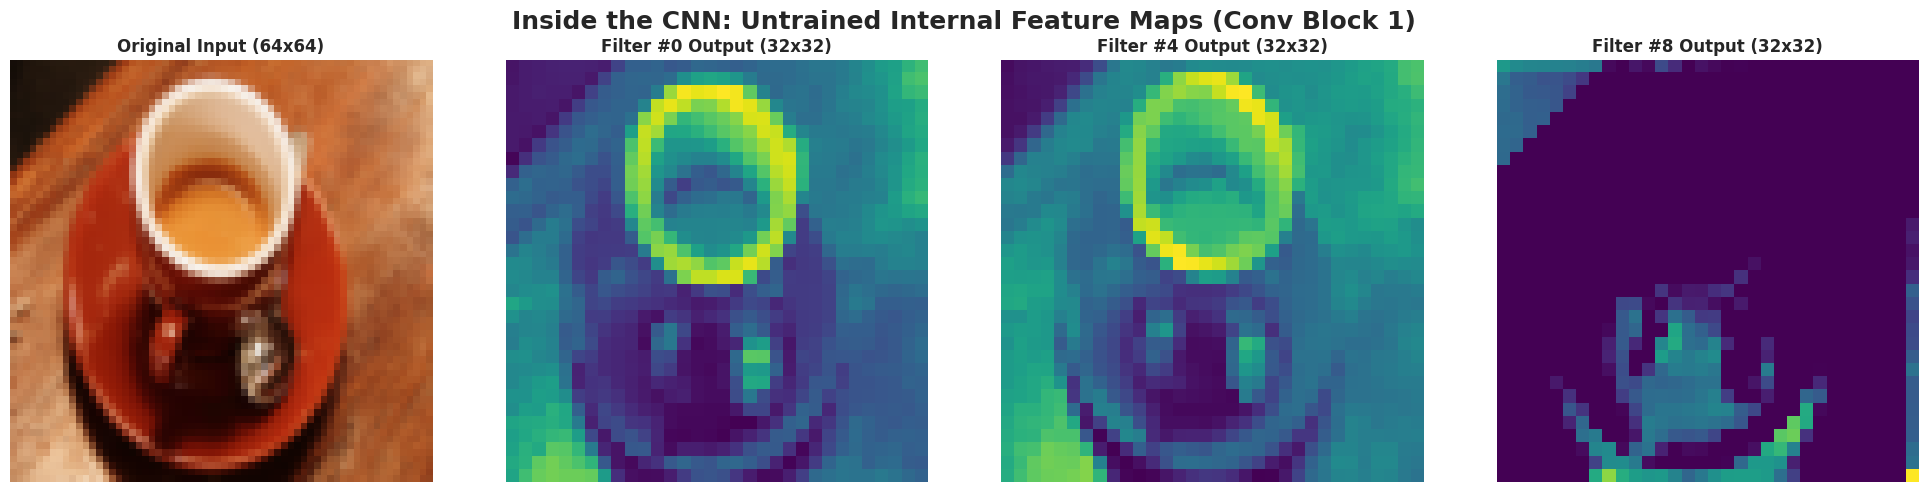


--- 💡 Structural Insight ---
Look at the feature maps! Even with completely random weights, the Convolutions are reacting to structural geometry. One filter might heavily highlight the rim of the coffee cup (bright yellow), while another highlights the background texture. These 16 distinct geometric maps are what eventually get flattened and handed to the Linear layer for decision-making.


In [6]:
# 1. Define the CNN Class Architecture
class SimpleImageClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        
        # --- PHASE 1: Feature Extractor ---
        # We group our Conv blocks using nn.Sequential for clean engineering
        self.feature_extractor = nn.Sequential(
            # Block 1
            # in_channels=3 (RGB), out_channels=16 (filters)
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Spatial: 64x64 -> 32x32
            
            # Block 2
            # in_channels MUST match the out_channels of the previous layer!
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # Spatial: 32x32 -> 16x16
        )
        
        # --- THE BRIDGE ---
        # Unrolls the (Batch_Size, 32, 16, 16) tensor into (Batch_Size, 8192)
        self.flatten = nn.Flatten()
        
        # --- PHASE 2: Classification Head ---
        self.classifier = nn.Sequential(
            # The input MUST be exactly 32 * 16 * 16 = 8192
            nn.Linear(in_features=32 * 16 * 16, out_features=512),
            nn.ReLU(),
            nn.Dropout(p=0.5), # Regularization to prevent overfitting
            nn.Linear(in_features=512, out_features=num_classes)
            # Notice: No Softmax here! We will use CrossEntropyLoss which expects raw logits.
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        vector = self.flatten(features)
        logits = self.classifier(vector)
        return logits

# 2. Instantiate the Network
model = SimpleImageClassifier(num_classes=10)

# 3. Prepare Real Data (skimage Coffee Cup)
numpy_coffee = data.coffee()
# We MUST resize to 64x64 to match our mathematical bridge calculation!
resized_coffee = resize(numpy_coffee, (64, 64), anti_aliasing=True)
coffee_tensor = torch.tensor(resized_coffee, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)

print("--- 📦 Tensor Dimension Tracking (The Forward Pass) ---")
print(f"1. Input Image Shape:      {coffee_tensor.shape}")

# 4. Extract Internal Feature Maps for Visualization
# We can physically intercept the data halfway through the network!
with torch.no_grad():
    # Pass through just Block 1 (Conv1 -> ReLU -> MaxPool1)
    block1_output = model.feature_extractor[0:3](coffee_tensor)
    print(f"2. After Conv Block 1:     {block1_output.shape}")
    
    # Pass through Block 2 (Conv2 -> ReLU -> MaxPool2)
    extracted_features = model.feature_extractor[3:6](block1_output)
    print(f"3. After Conv Block 2:     {extracted_features.shape}")
    
    # The Bridge
    flattened_vector = model.flatten(extracted_features)
    print(f"4. After Flattening:       {flattened_vector.shape}")
    
    # The Head
    final_predictions = model.classifier(flattened_vector)
    print(f"5. Final Output Logits:    {final_predictions.shape}")

# 5. Visualizing the Internal CNN Feature Maps
# Even though the network is UNTRAINED (random weights), we can see how the kernels 
# physically fragment the image into different mathematical edge and texture maps!
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Inside the CNN: Untrained Internal Feature Maps (Conv Block 1)", fontsize=18, fontweight='bold')

# Plot Original
axes[0].imshow(resized_coffee)
axes[0].set_title("Original Input (64x64)", fontweight='bold')
axes[0].axis('off')

# Plot 3 random feature channels from Block 1
# Output shape is [1, 16, 32, 32]. We will plot channel 0, 4, and 8.
for i, channel_idx in enumerate([0, 4, 8]):
    feature_map = block1_output[0, channel_idx, :, :].numpy()
    axes[i+1].imshow(feature_map, cmap='viridis')
    axes[i+1].set_title(f"Filter #{channel_idx} Output (32x32)", fontweight='bold')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

print("\n--- 💡 Structural Insight ---")
print("Look at the feature maps! Even with completely random weights, the Convolutions are reacting to structural geometry. One filter might heavily highlight the rim of the coffee cup (bright yellow), while another highlights the background texture. These 16 distinct geometric maps are what eventually get flattened and handed to the Linear layer for decision-making.")

## Real-World Use Case or Analogy:

Think of a Convolutional Neural Network like **A Car Manufacturing Plant**:

* **Phase 1: Feature Extractor (The Robotic Assembly Line)**:
* The raw steel (the Input Image) enters the factory.
* Station 1 (Conv1) uses specialized lasers (Kernels) to cut the steel into basic edges and curves.
* Station 2 (MaxPool1) compresses the metal scraps, throwing away the empty space to save room.
* Station 3 (Conv2) welds those basic curves into complex shapes like doors and wheels.
* At the end of the line, you don't have a car. You have 32 crates of highly specific, compressed car parts ($32 \times 16 \times 16$).


* **The Bridge (Flatten)**: The factory workers dump all 32 crates of parts onto a single, massive, straight conveyor belt so the executives can see everything at once (8,192 parts in a row).
* **Phase 2: The Classifier (The Executive Boardroom)**: The executives (Dense Layers) sit at the end of the conveyor belt. They look at all 8,192 parts simultaneously. An executive notices a steering wheel, 4 tires, and a sedan chassis. They apply logic (Weights) to these parts and confidently stamp the final output: **"This is a Honda Civic" (Class Prediction).**